In [5]:
# SESSION RESTORE - run this single cell after any session restart.
# Everything already computed is reloaded from disk; nothing is recomputed.
import os, glob, random
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.auto import tqdm

SEED, IMG_SIZE = 42, 224
random.seed(SEED); np.random.seed(SEED)
CLASS_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative"}

hits = glob.glob("/kaggle/input/**/train.csv", recursive=True)
DATA_ROOT = os.path.dirname(hits[0]) if hits else None
OUT_DIR   = "/kaggle/working"
FIG_DIR   = os.path.join(OUT_DIR, "figures")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
CACHE     = os.path.join(OUT_DIR, "processed")
for d in (FIG_DIR, SPLIT_DIR, CACHE):
    os.makedirs(d, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("splits  :", os.listdir(SPLIT_DIR) or "(empty)")
print("cache   :", os.listdir(CACHE) or "(empty)")
print("figures :", len(os.listdir(FIG_DIR)), "files")

DATA_ROOT: /kaggle/input/competitions/aptos2019-blindness-detection
splits  : ['val.csv', 'test.csv', 'train.csv']
cache   : ['X_test.npy', 'y_train.npy', 'y_test.npy', 'X_val.npy', 'y_val.npy', 'X_train.npy']
figures : 15 files


In [23]:
# S - Locate the attached dataset and create the output folders.
# The path is discovered rather than hard-coded, so the notebook runs unchanged
# wherever Kaggle mounts the competition data.
import os, glob

hits = glob.glob("/kaggle/input/**/train.csv", recursive=True)
assert hits, "train.csv not found - attach the dataset via '+ Add Input' in the right panel."
DATA_ROOT = os.path.dirname(hits[0])

OUT_DIR   = "/kaggle/working"
FIG_DIR   = os.path.join(OUT_DIR, "figures")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("Contents :", os.listdir(DATA_ROOT))

DATA_ROOT: /kaggle/input/competitions/aptos2019-blindness-detection
Contents : ['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']


In [7]:
# C1 - Imports, fixed random seed, and automatic detection of the dataset files
import os, glob, random
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

SEED = 42                                  # fixed seed -> identical results every run
random.seed(SEED); np.random.seed(SEED)

CLASS_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative"}

# Index every image file: {image_id: full path}
files = (glob.glob(f"{DATA_ROOT}/**/*.png", recursive=True) +
         glob.glob(f"{DATA_ROOT}/**/*.jpg", recursive=True))
IMG_INDEX = {Path(p).stem: p for p in files}
print(f"Image files found: {len(IMG_INDEX)}")

csv_files = glob.glob(f"{DATA_ROOT}/**/*.csv", recursive=True)
print("\nCSV files found:")
for c in csv_files:
    print("   ", c, pd.read_csv(c).shape)

Image files found: 5590

CSV files found:
    /kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv (1928, 2)
    /kaggle/input/competitions/aptos2019-blindness-detection/train.csv (3662, 2)
    /kaggle/input/competitions/aptos2019-blindness-detection/test.csv (1928, 1)


In [30]:
# C2 - Build the labelled table from train.csv only.
# sample_submission.csv also has id_code/diagnosis columns, but its labels are
# placeholder zeros for the unlabelled test set, so it must be excluded.
label_files = [c for c in csv_files
               if "sample_submission" not in os.path.basename(c).lower()]

frames = []
for c in label_files:
    t = pd.read_csv(c)
    t.columns = [col.strip().lower() for col in t.columns]
    if {"id_code", "diagnosis"}.issubset(t.columns):   # test.csv has no 'diagnosis' -> skipped
        print(f"Using labels from: {os.path.basename(c)}  ({len(t)} rows)")
        frames.append(t[["id_code", "diagnosis"]])

df = pd.concat(frames, ignore_index=True).drop_duplicates(subset="id_code")
df["id_code"] = (df["id_code"].astype(str)
                 .str.replace(".png", "", regex=False)
                 .str.replace(".jpg", "", regex=False))
df["path"]  = df["id_code"].map(IMG_INDEX)
missing = df["path"].isna().sum()
df = df.dropna(subset=["path"]).reset_index(drop=True)
df["stage"] = df["diagnosis"].map(CLASS_NAMES)

# ---- unlabelled test set: counted for the record, then excluded -------------
test_csv  = [c for c in csv_files if os.path.basename(c).lower() == "test.csv"]
n_test_csv = len(pd.read_csv(test_csv[0])) if test_csv else 0

test_dirs  = glob.glob(os.path.join(DATA_ROOT, "**", "test_images"), recursive=True)
n_test_img = len(os.listdir(test_dirs[0])) if test_dirs else 0

n_unlabelled = n_test_img or n_test_csv
# ----------------------------------------------------------------------------

print(f"\nLabelled images   : {len(df)}   (dropped, image not found: {missing})")
print(f"Unlabelled images : {n_unlabelled}   (competition test set - no ground truth, EXCLUDED)")
print(f"Total in dataset  : {len(df) + n_unlabelled}")
print("Grades present    :", sorted(df['diagnosis'].unique()))

df.drop_duplicates("diagnosis").sort_values("diagnosis")[["id_code", "diagnosis", "stage"]]

Using labels from: train.csv  (3662 rows)

Labelled images   : 3662   (dropped, image not found: 0)
Unlabelled images : 1928   (competition test set - no ground truth, EXCLUDED)
Total in dataset  : 5590
Grades present    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,id_code,diagnosis,stage
3,002c21358ce6,0,No DR
2,0024cdab0c1e,1,Mild
0,000c1434d8d7,2,Moderate
13,0104b032c141,3,Severe
1,001639a390f0,4,Proliferative


In [29]:
import glob, os
d = glob.glob('/kaggle/input/**/test_images', recursive=True)
print('Unlabelled test images:', len(os.listdir(d[0])) if d else 'test_images folder not found')

Unlabelled test images: 1928


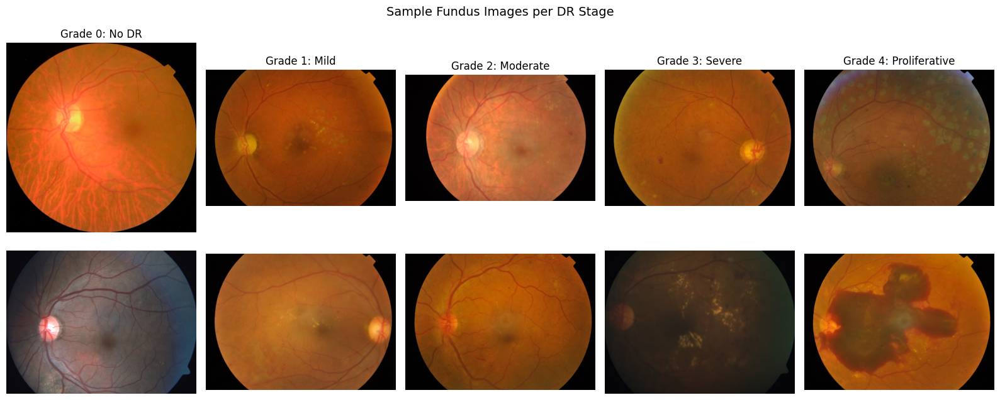

In [9]:
# C3 - Display two example fundus images from each DR grade (Figure 1)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for col, grade in enumerate(sorted(CLASS_NAMES)):
    for row, path in enumerate(df[df.diagnosis == grade].sample(2, random_state=SEED)["path"]):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)   # OpenCV loads BGR -> RGB
        axes[row, col].imshow(img); axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"Grade {grade}: {CLASS_NAMES[grade]}", fontsize=12)
plt.suptitle("Sample Fundus Images per DR Stage", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_samples.png", dpi=150, bbox_inches="tight")
plt.show()

                   Stage  Images  Percentage (%)
diagnosis                                       
0                  No DR    1805            49.3
1                   Mild     370            10.1
2               Moderate     999            27.3
3                 Severe     193             5.3
4          Proliferative     295             8.1

Total images: 3662
Imbalance ratio (largest/smallest): 9.4 : 1


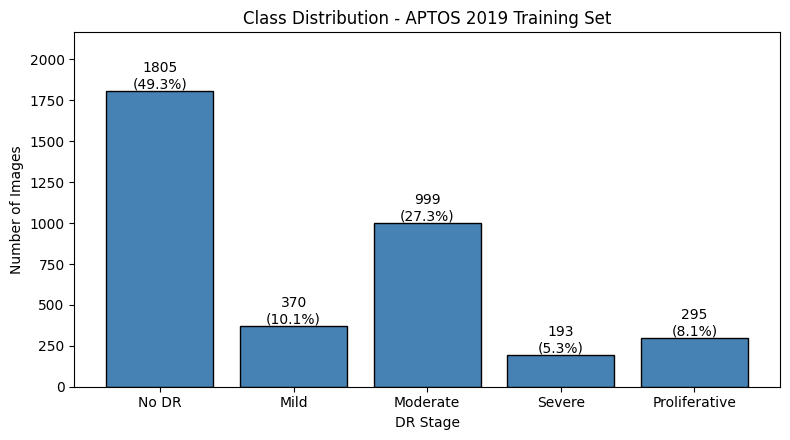

In [6]:
# C4 - Count images per class and plot the distribution
counts = df["diagnosis"].value_counts().sort_index()
dist = pd.DataFrame({
    "Stage": [CLASS_NAMES[i] for i in counts.index],
    "Images": counts.values,
    "Percentage (%)": (counts.values / len(df) * 100).round(1)}, index=counts.index)
print(dist)
print(f"\nTotal images: {len(df)}")
print(f"Imbalance ratio (largest/smallest): {counts.max()/counts.min():.1f} : 1")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dist["Stage"], dist["Images"], color="steelblue", edgecolor="black")
ax.bar_label(bars, labels=[f"{n}\n({p}%)" for n, p in zip(dist["Images"], dist["Percentage (%)"])])
ax.set(title="Class Distribution - APTOS 2019 Training Set", xlabel="DR Stage",
       ylabel="Number of Images", ylim=(0, counts.max()*1.2))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
# C5 - Read each image's header only (fast) to collect width and height
def get_size(p):
    with Image.open(p) as im:
        return im.size

df["width"], df["height"] = zip(*[get_size(p) for p in tqdm(df["path"], desc="Reading sizes")])

print(df[["width", "height"]].describe().round(0))
print("\nDistinct resolutions:", df.groupby(["width", "height"]).ngroups)
print("\nMost common resolutions:\n", df.value_counts(["width", "height"]).head(5))

Reading sizes:   0%|          | 0/3662 [00:00<?, ?it/s]

        width  height
count  3662.0  3662.0
mean   2015.0  1527.0
std     884.0   543.0
min     474.0   358.0
25%    1050.0  1050.0
50%    2144.0  1536.0
75%    2588.0  1958.0
max    4288.0  2848.0

Distinct resolutions: 17

Most common resolutions:
 width  height
1050   1050      974
2416   1736      638
2588   1958      533
3216   2136      410
2048   1536      351
Name: count, dtype: int64


In [8]:
# C6 - Detect near-duplicate images using difference hashing (dHash).
# dHash reduces an image to a small grayscale grid and records whether each pixel
# is brighter than its right-hand neighbour, producing a 256-bit fingerprint that
# survives resizing and re-encoding.
HASH_SIZE, DUP_THRESHOLD = 16, 8      # 16x16 = 256-bit hash; <=8 differing bits = duplicate

def dhash_bits(path, hash_size=HASH_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (hash_size + 1, hash_size), interpolation=cv2.INTER_AREA)
    return (img[:, 1:] > img[:, :-1]).flatten()

hashes = np.array([dhash_bits(p) for p in tqdm(df["path"], desc="Hashing")], dtype=np.float32)

# Hamming distance = number of differing bits between every pair of images
same    = hashes @ hashes.T + (1 - hashes) @ (1 - hashes).T
hamming = HASH_SIZE * HASH_SIZE - same

# Group mutually near-duplicate images together
_, group_ids = connected_components(csr_matrix(hamming <= DUP_THRESHOLD), directed=False)
df["group"]      = group_ids
df["group_size"] = df.groupby("group")["id_code"].transform("count")
df["n_labels"]   = df.groupby("group")["diagnosis"].transform("nunique")

dup_df = df[df.group_size > 1]
print(f"Images in duplicate groups:     {len(dup_df)}")
print(f"Duplicate groups:               {dup_df['group'].nunique()}")
print(f"Groups with conflicting labels: {dup_df[dup_df.n_labels > 1]['group'].nunique()}")

Hashing:   0%|          | 0/3662 [00:00<?, ?it/s]

Images in duplicate groups:     309
Duplicate groups:               139
Groups with conflicting labels: 37


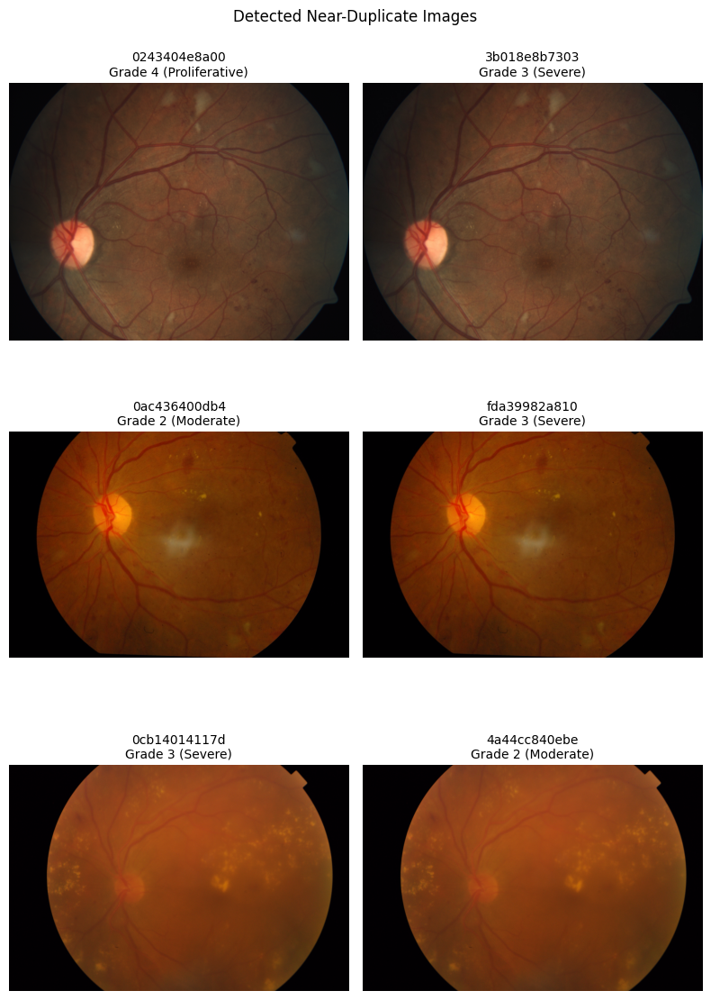

In [9]:
# C7 - Show example duplicate pairs, prioritising those with conflicting labels
ordered = pd.concat([dup_df[dup_df.n_labels > 1], dup_df[dup_df.n_labels == 1]])
groups  = ordered["group"].unique()[:3]

if len(groups) == 0:
    print("No duplicates found.")
else:
    fig, axes = plt.subplots(len(groups), 2, figsize=(8, 4*len(groups)), squeeze=False)
    for r, g in enumerate(groups):
        for c, (_, row) in enumerate(dup_df[dup_df.group == g].head(2).iterrows()):
            axes[r, c].imshow(cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB))
            axes[r, c].set_title(f"{row['id_code']}\nGrade {row['diagnosis']} ({row['stage']})",
                                 fontsize=10)
            axes[r, c].axis("off")
    plt.suptitle("Detected Near-Duplicate Images")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig3_duplicates.png", dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
# C8 - Cleaning policy:
#   (1) duplicate groups with CONFLICTING labels -> removed entirely (true grade unknown)
#   (2) duplicate groups with CONSISTENT labels  -> keep one image (prevents data leakage)
df_clean = (df[df.n_labels == 1]
            .drop_duplicates(subset="group", keep="first")
            .reset_index(drop=True))

print(f"Original images: {len(df)}")
print(f"Removed:         {len(df) - len(df_clean)}")
print(f"Clean dataset:   {len(df_clean)}")
print("\nImages per class after cleaning:")
print(df_clean["diagnosis"].value_counts().sort_index())

Original images: 3662
Removed:         207
Clean dataset:   3455

Images per class after cleaning:
diagnosis
0    1765
1     338
2     921
3     167
4     264
Name: count, dtype: int64


                   Train  Validation  Test
0 - No DR           1235         265   265
1 - Mild             236          51    51
2 - Moderate         645         138   138
3 - Severe           117          25    25
4 - Proliferative    185          39    40
Total               2418         518   519

No overlap between splits - OK


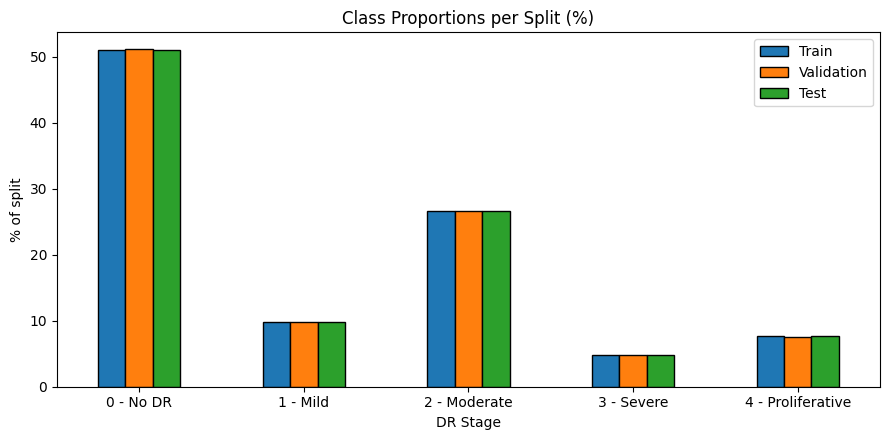

Splits saved to /kaggle/working/splits


In [11]:
# C9 - Split 70% train / 15% validation / 15% test, keeping class proportions equal
train_df, temp_df = train_test_split(df_clean, test_size=0.30,
                                     stratify=df_clean["diagnosis"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                     stratify=temp_df["diagnosis"], random_state=SEED)

split_table = pd.DataFrame({"Train": train_df.diagnosis.value_counts(),
                            "Validation": val_df.diagnosis.value_counts(),
                            "Test": test_df.diagnosis.value_counts()}).sort_index()
split_table.index = [f"{i} - {CLASS_NAMES[i]}" for i in split_table.index]
split_table.loc["Total"] = split_table.sum()
print(split_table)

# Leakage check: no duplicate group may appear in more than one split
for a, b, name in [(train_df, val_df, "train/val"), (train_df, test_df, "train/test"),
                   (val_df, test_df, "val/test")]:
    assert not set(a["group"]) & set(b["group"]), f"Leakage between {name}!"
print("\nNo overlap between splits - OK")

pct = split_table.drop("Total") / split_table.loc["Total"] * 100
ax = pct.plot(kind="bar", figsize=(9, 4.5), edgecolor="black")
ax.set(title="Class Proportions per Split (%)", xlabel="DR Stage", ylabel="% of split")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_split_proportions.png", dpi=200, bbox_inches="tight")
plt.show()

cols = ["id_code", "diagnosis", "path"]
train_df[cols].to_csv(f"{SPLIT_DIR}/train.csv", index=False)
val_df[cols].to_csv(f"{SPLIT_DIR}/val.csv", index=False)
test_df[cols].to_csv(f"{SPLIT_DIR}/test.csv", index=False)
print("Splits saved to", SPLIT_DIR)

In [12]:
# C10 - Load the saved partition (keeps every later stage on the same split)
train_df = pd.read_csv(f"{SPLIT_DIR}/train.csv")
val_df   = pd.read_csv(f"{SPLIT_DIR}/val.csv")
test_df  = pd.read_csv(f"{SPLIT_DIR}/test.csv")
print(f"Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")

Train 2418 | Val 518 | Test 519


In [13]:
# C11 - Preprocessing pipeline.
# Applied identically to every image and derived from no dataset statistics,
# so it cannot leak information between the training, validation and test subsets.
IMG_SIZE = 224          # input size expected by the pretrained CNN

def crop_retina(img, tol=7):
    """Remove the black border by cropping to the retinal region."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img                                  # safeguard for near-black images
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def pad_to_square(img, value=0):
    """Pad the shorter side so resizing does not distort the circular retina.
    'value' sets the padding colour so it can match the processed background."""
    h, w = img.shape[:2]
    d = abs(h - w)
    p1, p2 = d // 2, d - d // 2
    if h < w:
        return cv2.copyMakeBorder(img, p1, p2, 0, 0, cv2.BORDER_CONSTANT, value=[value]*3)
    return cv2.copyMakeBorder(img, 0, 0, p1, p2, cv2.BORDER_CONSTANT, value=[value]*3)

def apply_clahe(img, clip=2.0, grid=(8, 8)):
    """Contrast-limited adaptive histogram equalisation on the L channel of LAB.
    Operating on L preserves the colour distinction between haemorrhages (red)
    and exudates (yellow)."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

def ben_graham(img, sigma=10):
    """Subtract a heavily blurred copy to remove slow illumination gradients
    while enhancing local edges such as lesion boundaries and vessels."""
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blur, -4, 128)

def preprocess(path, size=IMG_SIZE):
    """Full pipeline: load -> crop -> denoise -> CLAHE -> illumination
    normalisation -> square pad -> resize. Returns a uint8 RGB image."""
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = crop_retina(img)
    img = cv2.medianBlur(img, 3)          # suppresses sensor noise, keeps lesion edges
    img = apply_clahe(img)
    img = ben_graham(img)
    img = pad_to_square(img, value=128)   # matches the normalised background - no false edge
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

print("Pipeline defined. Output:", preprocess(train_df.path.iloc[0]).shape)

Pipeline defined. Output: (224, 224, 3)


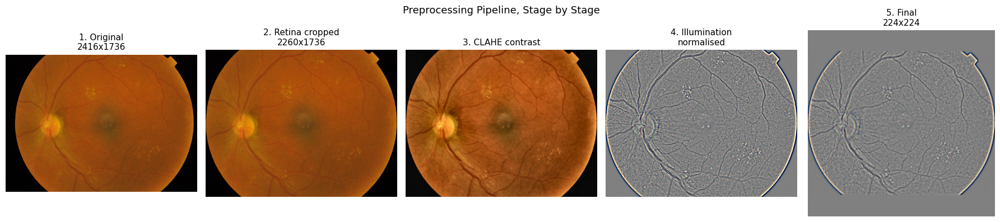

In [14]:
# C12 - Show the effect of each stage on one image (Figure 7)
p = train_df[train_df.diagnosis == 2].path.iloc[0]        # a moderate case with visible lesions

orig    = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
cropped = crop_retina(orig)
denoise = cv2.medianBlur(cropped, 3)
clahed  = apply_clahe(denoise)
bened   = ben_graham(clahed)
final   = cv2.resize(pad_to_square(bened, 128), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

stages = [(orig, f"1. Original\n{orig.shape[1]}x{orig.shape[0]}"),
          (cropped, f"2. Retina cropped\n{cropped.shape[1]}x{cropped.shape[0]}"),
          (clahed, "3. CLAHE contrast"),
          (bened, "4. Illumination\nnormalised"),
          (final, f"5. Final\n{IMG_SIZE}x{IMG_SIZE}")]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (im, t) in zip(axes, stages):
    ax.imshow(im); ax.set_title(t, fontsize=11); ax.axis("off")
plt.suptitle("Preprocessing Pipeline, Stage by Stage", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig5_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

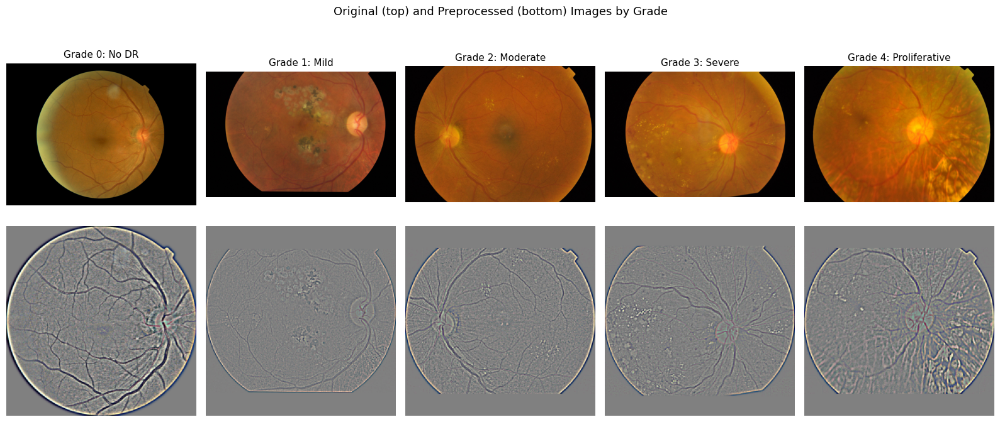

In [15]:
# C13 - Compare original and preprocessed images across all five grades (Figure 8)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for col, g in enumerate(sorted(CLASS_NAMES)):
    path = train_df[train_df.diagnosis == g].path.iloc[0]
    axes[0, col].imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Grade {g}: {CLASS_NAMES[g]}", fontsize=11)
    axes[1, col].imshow(preprocess(path))
    for r in (0, 1):
        axes[r, col].axis("off")
plt.suptitle("Original (top) and Preprocessed (bottom) Images by Grade", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig6_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# C14 - Preprocess every image once and cache as arrays.
# Caching removes preprocessing as a source of variation between training runs
# and avoids repeating the work at every epoch.
CACHE = "/kaggle/working/processed"
os.makedirs(CACHE, exist_ok=True)

def build_cache(frame, name):
    X = np.zeros((len(frame), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    for i, p in enumerate(tqdm(frame["path"], desc=name)):
        X[i] = preprocess(p)
    np.save(f"{CACHE}/X_{name}.npy", X)
    np.save(f"{CACHE}/y_{name}.npy", frame["diagnosis"].values)
    print(f"{name}: {X.shape}  ->  {X.nbytes/1e6:.0f} MB")

for frame, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    build_cache(frame, name)

train:   0%|          | 0/2418 [00:00<?, ?it/s]

train: (2418, 224, 224, 3)  ->  364 MB


val:   0%|          | 0/518 [00:00<?, ?it/s]

val: (518, 224, 224, 3)  ->  78 MB


test:   0%|          | 0/519 [00:00<?, ?it/s]

test: (519, 224, 224, 3)  ->  78 MB


In [17]:
# C15 - Quantify the effect of preprocessing on image consistency and local detail,
# measured on a 300-image training sample before and after the pipeline.
sample = train_df.sample(300, random_state=SEED)

def stats(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return g.mean(), cv2.Laplacian(g, cv2.CV_64F).var()   # brightness, local detail

before = np.array([stats(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
                   for p in tqdm(sample.path, desc="before")])
after  = np.array([stats(preprocess(p)) for p in tqdm(sample.path, desc="after")])

print(f"{'':22}{'before':>12}{'after':>12}")
print(f"{'Mean brightness':22}{before[:,0].mean():12.1f}{after[:,0].mean():12.1f}")
print(f"{'SD of brightness':22}{before[:,0].std():12.1f}{after[:,0].std():12.1f}   <- lower = more consistent")
print(f"{'Mean edge variance':22}{before[:,1].mean():12.1f}{after[:,1].mean():12.1f}   <- higher = sharper detail")

before:   0%|          | 0/300 [00:00<?, ?it/s]

after:   0%|          | 0/300 [00:00<?, ?it/s]

                            before       after
Mean brightness               67.8       128.0
SD of brightness              18.1         0.1   <- lower = more consistent
Mean edge variance            24.1      2684.8   <- higher = sharper detail


In [18]:
# C16 - Load the preprocessed arrays cached in Task 2
CACHE = "/kaggle/working/processed"
X_train = np.load(f"{CACHE}/X_train.npy"); y_train = np.load(f"{CACHE}/y_train.npy")
X_val   = np.load(f"{CACHE}/X_val.npy");   y_val   = np.load(f"{CACHE}/y_val.npy")
X_test  = np.load(f"{CACHE}/X_test.npy");  y_test  = np.load(f"{CACHE}/y_test.npy")
print(f"Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")

Train (2418, 224, 224, 3) | Val (518, 224, 224, 3) | Test (519, 224, 224, 3)


In [19]:
# C17 - Augmentation pipeline (training data only).
# Each transform reproduces variation that genuinely occurs between fundus
# photographs, so the network learns invariance to acquisition conditions
# rather than to artificial distortions.
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"      # suppress TensorFlow info/warning noise

import tensorflow as tf
from tensorflow.keras import layers

# Regions vacated by geometric transforms are filled with the mid-grey background
# of the preprocessed images. Reflection (the Keras default) would duplicate
# vessels into the corners, producing anatomically impossible retinas.
FILL = dict(fill_mode="constant", fill_value=128.0)

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),        # left/right eyes, camera orientation
    layers.RandomRotation(0.25, **FILL),                 # retinas have no fixed orientation
    layers.RandomZoom(0.15, **FILL),                     # varying field of view
    layers.RandomTranslation(0.10, 0.10, **FILL),        # optic disc is not always centred
    layers.RandomContrast(0.15),                         # residual exposure differences
], name="augmentation")

print("Augmentation layers:", [l.name for l in augmenter.layers])

Augmentation layers: ['random_flip', 'random_rotation', 'random_zoom', 'random_translation', 'random_contrast']


I0000 00:00:1790442824.605768      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790442824.608699      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


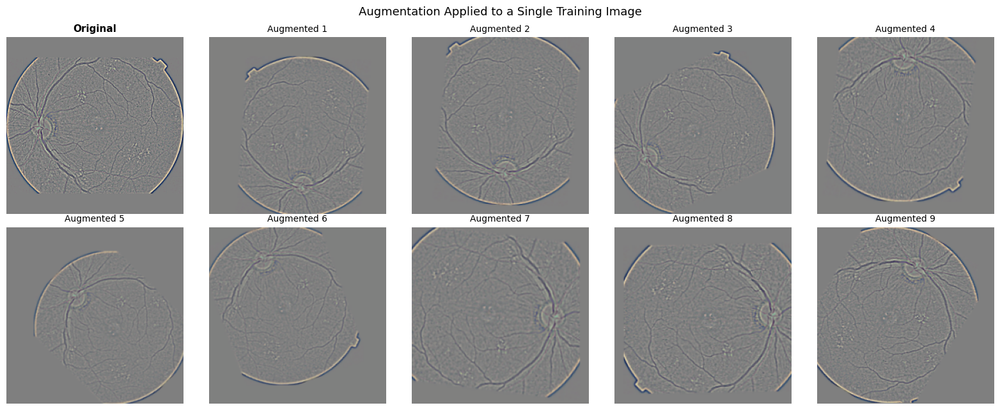

In [20]:
# C18 - Show nine augmented variants of one training image (Figure 7)
idx = np.where(y_train == 2)[0][0]                 # a moderate case with visible lesions
img = X_train[idx]

fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
axes[0, 0].imshow(img)
axes[0, 0].set_title("Original", fontsize=11, weight="bold")
axes[0, 0].axis("off")

for i, ax in enumerate(list(axes.flat)[1:]):
    aug = augmenter(tf.expand_dims(tf.cast(img, tf.float32), 0), training=True)[0]
    ax.imshow(np.clip(aug.numpy(), 0, 255).astype("uint8"))
    ax.set_title(f"Augmented {i+1}", fontsize=10)
    ax.axis("off")

plt.suptitle("Augmentation Applied to a Single Training Image", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig7_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# C19 - Compute class weights to counteract the 9.4:1 imbalance.
# Weighting rescales each class's contribution to the loss so that minority
# classes influence learning in proportion to their clinical importance rather
# than their frequency. Unlike oversampling it introduces no duplicate images.
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

wt = pd.DataFrame({
    "Stage":        [CLASS_NAMES[c] for c in classes],
    "Train images": [int(np.sum(y_train == c)) for c in classes],
    "Share (%)":    [round(float(np.mean(y_train == c)) * 100, 1) for c in classes],
    "Weight":       np.round(weights, 3)}, index=classes)
print(wt)
print(f"\nWeight ratio (max/min): {weights.max()/weights.min():.1f} : 1")

           Stage  Train images  Share (%)  Weight
0          No DR          1235       51.1   0.392
1           Mild           236        9.8   2.049
2       Moderate           645       26.7   0.750
3         Severe           117        4.8   4.133
4  Proliferative           185        7.7   2.614

Weight ratio (max/min): 10.6 : 1


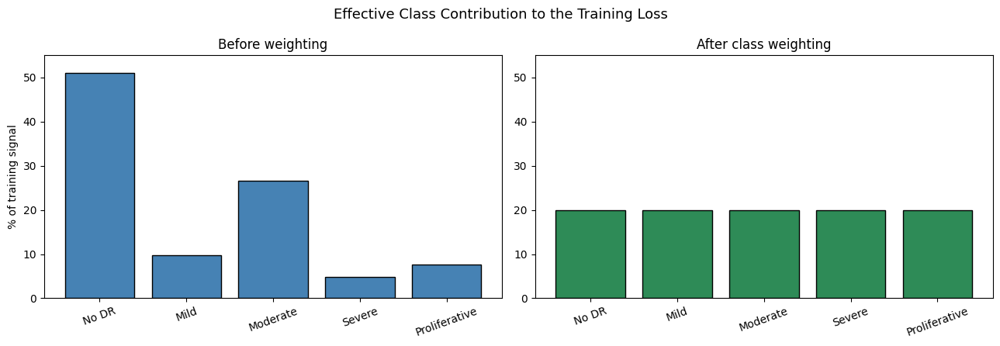

In [22]:
# C20 - Visualise the effect of weighting: raw counts vs weighted contribution (Figure 8)
counts   = np.array([np.sum(y_train == c) for c in classes], dtype=float)
weighted = counts * weights                        # each class's share of the weighted loss

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
names = [CLASS_NAMES[c] for c in classes]

axes[0].bar(names, counts / counts.sum() * 100, color="steelblue", edgecolor="black")
axes[0].set(title="Before weighting", ylabel="% of training signal", ylim=(0, 55))
axes[1].bar(names, weighted / weighted.sum() * 100, color="seagreen", edgecolor="black")
axes[1].set(title="After class weighting", ylim=(0, 55))
for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Effective Class Contribution to the Training Loss", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig8_class_weights.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
# C21 - Confirm GPU availability and define the training configuration.
# All hyperparameters are declared here so experiments differ in one
# controlled variable at a time.
print("GPU devices:", tf.config.list_physical_devices('GPU'))

IMG_SIZE    = 224
BATCH_SIZE  = 32
N_CLASSES   = 5
EPOCHS_HEAD = 12      # phase 1: train the new head with the backbone frozen
EPOCHS_FT   = 18      # phase 2: fine-tune the upper backbone layers

tf.random.set_seed(SEED)     # reproducible weight initialisation and shuffling

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [24]:
# C22 - Build tf.data pipelines.
# Augmentation is applied on the fly to the training set only; validation and
# test sets are left unmodified so they give an unbiased performance estimate.
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED).batch(BATCH_SIZE)
        ds = ds.map(lambda x, l: (augmenter(x, training=True), l), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)
print("Pipelines ready:", train_ds.element_spec[0].shape)

Pipelines ready: (None, 224, 224, 3)


In [25]:
# C23 - Build a transfer-learning model from a pretrained backbone.
# The ImageNet classifier head is discarded and replaced with a task-specific
# head sized for five classes; the backbone is frozen initially so the randomly
# initialised head does not destroy the pretrained features with large gradients.
from tensorflow.keras import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dropout, Dense,
                                     BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam

BACKBONES = {
    "EfficientNetB0": (tf.keras.applications.EfficientNetB0,
                       tf.keras.applications.efficientnet.preprocess_input),
    "ResNet50":       (tf.keras.applications.ResNet50,
                       tf.keras.applications.resnet50.preprocess_input),
}

def build_model(name, dropout=0.4, lr=1e-3):
    base_fn, preproc = BACKBONES[name]
    base = base_fn(include_top=False, weights="imagenet",
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False                       # phase 1: feature extraction only

    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preproc(inp)                             # each backbone expects its own scaling
    x = base(x, training=False)                  # keep BatchNorm in inference mode
    x = GlobalAveragePooling2D()(x)              # pooling, not flatten: far fewer parameters
    x = BatchNormalization()(x)                  # stabilises the head's input distribution
    x = Dropout(dropout)(x)                      # regularisation for a small dataset
    x = Dense(256, activation="relu")(x)
    x = Dropout(dropout)(x)
    out = Dense(N_CLASSES, activation="softmax")(x)

    model = Model(inp, out, name=f"{name}_DR")
    model.compile(optimizer=Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model, base

m, _ = build_model("EfficientNetB0")
print(f"Total {m.count_params():,} | Trainable {sum(np.prod(w.shape) for w in m.trainable_weights):,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total 4,383,912 | Trainable 331,781


In [26]:
# C24 - Two-phase training: head training, then fine-tuning of the upper backbone.
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)

def callbacks_for(tag, patience=5):
    return [
        EarlyStopping(monitor="val_loss", patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2,
                          min_lr=1e-7, verbose=1),
        ModelCheckpoint(f"/kaggle/working/{tag}.keras", monitor="val_loss",
                        save_best_only=True, verbose=0),
    ]

def train_model(name, dropout=0.4, lr=1e-3, ft_lr=1e-5, unfreeze=40, tag=None):
    tag = tag or name
    model, base = build_model(name, dropout, lr)

    # Phase 1 - train only the new head
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                   class_weight=class_weights, callbacks=callbacks_for(f"{tag}_p1"),
                   verbose=1)

    # Phase 2 - unfreeze the top layers and fine-tune at a much lower rate,
    # so pretrained features are refined rather than overwritten
    base.trainable = True
    for layer in base.layers[:-unfreeze]:
        layer.trainable = False
    for layer in base.layers:                    # BatchNorm statistics stay frozen
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
    model.compile(optimizer=Adam(ft_lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
                   class_weight=class_weights, callbacks=callbacks_for(f"{tag}_p2"),
                   verbose=1)

    hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
    return model, hist, len(h1.history["loss"])

In [27]:
# C25 - Train both candidate architectures under identical conditions,
# so the comparison isolates the effect of the backbone.
import time
results = {}

for name in ["EfficientNetB0", "ResNet50"]:
    print(f"\n{'='*20} {name} {'='*20}")
    t0 = time.time()
    model, hist, split = train_model(name)
    val_acc = max(hist["val_accuracy"])
    results[name] = {"model": model, "hist": hist, "split": split,
                     "val_acc": val_acc, "mins": (time.time()-t0)/60,
                     "params": model.count_params()}
    print(f"{name}: best val accuracy {val_acc:.4f} in {results[name]['mins']:.0f} min")


==================== EfficientNetB0 ====================
Epoch 1/12


2026-09-26 17:19:51.059017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:19:51.202478: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:19:51.546728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:19:51.687909: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:19:52.474419: E external/local_xla/xla/stream_

75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5272 - loss: 1.9777

2026-09-26 17:20:17.108189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:17.248209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:17.574107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:17.714003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:18.487924: E external/local_xla/xla/stream_

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5275 - loss: 1.9759

2026-09-26 17:20:37.341934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:37.476480: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:37.790951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:37.930483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:20:38.677605: E external/local_xla/xla/stream_

76/76 ━━━━━━━━━━━━━━━━━━━━ 72s 572ms/step - accuracy: 0.5533 - loss: 1.8407 - val_accuracy: 0.6602 - val_loss: 0.8477 - learning_rate: 0.0010
Epoch 2/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.5993 - loss: 1.4512 - val_accuracy: 0.6429 - val_loss: 0.8053 - learning_rate: 0.0010
Epoch 3/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.5980 - loss: 1.3542 - val_accuracy: 0.7239 - val_loss: 0.7767 - learning_rate: 0.0010
Epoch 4/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.6427 - loss: 1.2536 - val_accuracy: 0.7239 - val_loss: 0.7325 - learning_rate: 0.0010
Epoch 5/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.6435 - loss: 1.2365 - val_accuracy: 0.7066 - val_loss: 0.7263 - learning_rate: 0.0010
Epoch 6/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.6406 - loss: 1.1529 - val_accuracy: 0.7259 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 7/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.6253 - loss: 1.1560 - val_

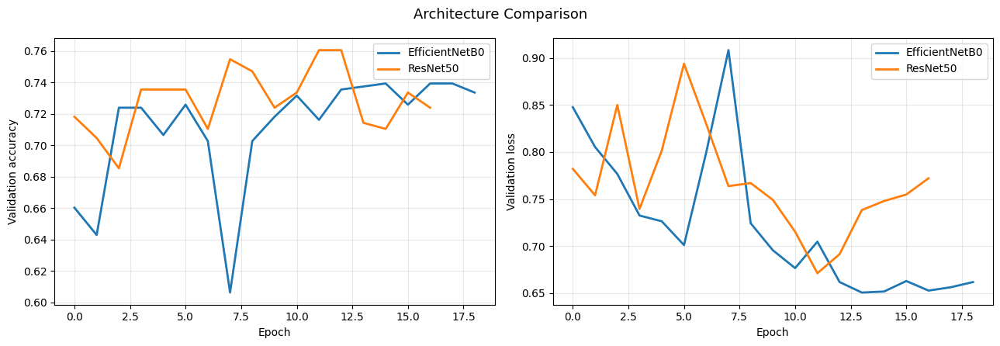

                Parameters (M)  Best val accuracy  Training time (min)
EfficientNetB0             4.4             0.7394                  6.0
ResNet50                  24.1             0.7606                  5.0


In [28]:
# C26 - Compare validation performance of the two architectures (Figure 9)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in ["EfficientNetB0", "ResNet50"]:
    r = results[name]
    axes[0].plot(r["hist"]["val_accuracy"], label=name, linewidth=2)
    axes[1].plot(r["hist"]["val_loss"], label=name, linewidth=2)
for ax, ylab in zip(axes, ["Validation accuracy", "Validation loss"]):
    ax.set(xlabel="Epoch", ylabel=ylab); ax.legend(); ax.grid(alpha=.3)
plt.suptitle("Architecture Comparison", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig9_architectures.png", dpi=200, bbox_inches="tight")
plt.show()

summary = pd.DataFrame({n: {"Parameters (M)": round(results[n]["params"]/1e6, 1),
                            "Best val accuracy": round(results[n]["val_acc"], 4),
                            "Training time (min)": round(results[n]["mins"])}
                        for n in ["EfficientNetB0", "ResNet50"]}).T
print(summary)

In [29]:
# C27 - Tune dropout and fine-tuning learning rate on the better backbone.
# Exactly one variable changes per configuration, so any difference is attributable.
BEST = max(["EfficientNetB0", "ResNet50"], key=lambda n: results[n]["val_acc"])
print("Tuning:", BEST)

configs = [
    {"dropout": 0.3, "ft_lr": 1e-5},
    {"dropout": 0.4, "ft_lr": 1e-5},     # identical to the C25 baseline
    {"dropout": 0.5, "ft_lr": 1e-5},
    {"dropout": 0.4, "ft_lr": 3e-5},
    {"dropout": 0.4, "ft_lr": 3e-6},
]

tuning = []
for i, cfg in enumerate(configs):
    print(f"\n--- config {i+1}/{len(configs)}: {cfg} ---")
    model, hist, _ = train_model(BEST, tag=f"tune{i}", **cfg)
    tuning.append({**cfg,
                   "val_accuracy": round(max(hist["val_accuracy"]), 4),
                   "val_loss": round(min(hist["val_loss"]), 4)})
    results[f"tune{i}"] = {"model": model, "hist": hist,
                           "val_acc": max(hist["val_accuracy"])}

tune_df = pd.DataFrame(tuning)
print("\n", tune_df.sort_values("val_accuracy", ascending=False))

Tuning: ResNet50

--- config 1/5: {'dropout': 0.3, 'ft_lr': 1e-05} ---
Epoch 1/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 36s 314ms/step - accuracy: 0.5864 - loss: 1.7459 - val_accuracy: 0.7375 - val_loss: 0.6831 - learning_rate: 0.0010
Epoch 2/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - accuracy: 0.6154 - loss: 1.4505 - val_accuracy: 0.6911 - val_loss: 0.7372 - learning_rate: 0.0010
Epoch 3/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 191ms/step - accuracy: 0.6282 - loss: 1.3170 - val_accuracy: 0.7490 - val_loss: 0.6821 - learning_rate: 0.0010
Epoch 4/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - accuracy: 0.6547 - loss: 1.1745 - val_accuracy: 0.7181 - val_loss: 0.7379 - learning_rate: 0.0010
Epoch 5/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6759 - loss: 1.1529
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - accuracy: 0.6667 - loss: 1.1483 - val_accuracy: 0.6795 - val_loss: 0.8483 - learning_rate: 0.0010
Epoch 6/12
76

In [30]:
# C27b - Quantify run-to-run variability by repeating the best configuration
# with three random seeds. Without this, differences between configurations
# cannot be distinguished from random variation.
best_i   = int(tune_df["val_accuracy"].idxmax())
best_cfg = configs[best_i]
print("Repeating configuration:", best_cfg)

repeats = []
for s in [1, 2, 3]:
    tf.random.set_seed(s)
    print(f"\n--- repeat with seed {s} ---")
    model, hist, _ = train_model(BEST, tag=f"rep{s}", **best_cfg)
    acc = max(hist["val_accuracy"])
    repeats.append({"seed": s, "val_accuracy": round(acc, 4)})
    results[f"rep{s}"] = {"model": model, "hist": hist, "val_acc": acc}

rep_df = pd.DataFrame(repeats)
print("\n", rep_df)
print(f"Mean {rep_df.val_accuracy.mean():.4f} | SD {rep_df.val_accuracy.std():.4f} | "
      f"Range {rep_df.val_accuracy.max() - rep_df.val_accuracy.min():.4f}")

Repeating configuration: {'dropout': 0.3, 'ft_lr': 1e-05}

--- repeat with seed 1 ---
Epoch 1/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 37s 314ms/step - accuracy: 0.5757 - loss: 1.7236 - val_accuracy: 0.7027 - val_loss: 0.7554 - learning_rate: 0.0010
Epoch 2/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - accuracy: 0.6175 - loss: 1.4073 - val_accuracy: 0.7394 - val_loss: 0.7187 - learning_rate: 0.0010
Epoch 3/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - accuracy: 0.6518 - loss: 1.3554 - val_accuracy: 0.7220 - val_loss: 0.8709 - learning_rate: 0.0010
Epoch 4/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6479 - loss: 1.2373
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - accuracy: 0.6456 - loss: 1.2472 - val_accuracy: 0.6795 - val_loss: 0.8513 - learning_rate: 0.0010
Epoch 5/12
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.6493 - loss: 1.1806 - val_accuracy: 0.7046 - val_loss: 0.7946 - learning_rate: 3.000

In [40]:
# C28 - Select the final model as the best-performing run across all experiments,
# judged on validation accuracy alone. Every saved phase-2 checkpoint is
# re-evaluated on the validation subset so the selection is explicit and
# verifiable, and the chosen file is checked after saving.
import glob, os, shutil

val_scores = {}
for f in sorted(glob.glob("/kaggle/working/*_p2.keras")):
    m = tf.keras.models.load_model(f)
    acc = (m.predict(X_val, batch_size=32, verbose=0).argmax(1) == y_val).mean()
    val_scores[f] = acc
    print(f"{os.path.basename(f):24s} val acc {acc:.4f}")

winner = max(val_scores, key=val_scores.get)
shutil.copy(winner, "/kaggle/working/final_model.keras")

# Verification: the saved file must reproduce the selected checkpoint exactly
check = tf.keras.models.load_model("/kaggle/working/final_model.keras")
a_disk = (check.predict(X_val, batch_size=32, verbose=0).argmax(1) == y_val).mean()

print(f"\nSelected: {os.path.basename(winner)}  val acc {val_scores[winner]:.4f}")
print(f"Reloaded final_model.keras: {a_disk:.4f}")
assert abs(val_scores[winner] - a_disk) < 1e-6, "Saved model does not match!"
print("Verified.")

# Keep the matching history for the training-curve figure
tag = os.path.basename(winner).replace("_p2.keras", "")
best_hist = results[tag]["hist"] if tag in results else best_hist
np.save("/kaggle/working/final_history.npy", best_hist, allow_pickle=True)
print("History saved for:", tag)

EfficientNetB0_p2.keras  val acc 0.7375
ResNet50_p2.keras        val acc 0.7606
rep1_p2.keras            val acc 0.7355
rep2_p2.keras            val acc 0.7375
rep3_p2.keras            val acc 0.6931
tune0_p2.keras           val acc 0.7741
tune1_p2.keras           val acc 0.6583
tune2_p2.keras           val acc 0.7066
tune3_p2.keras           val acc 0.7548
tune4_p2.keras           val acc 0.7124

Selected: tune0_p2.keras  val acc 0.7741
Reloaded final_model.keras: 0.7741
Verified.
History saved for: tune0


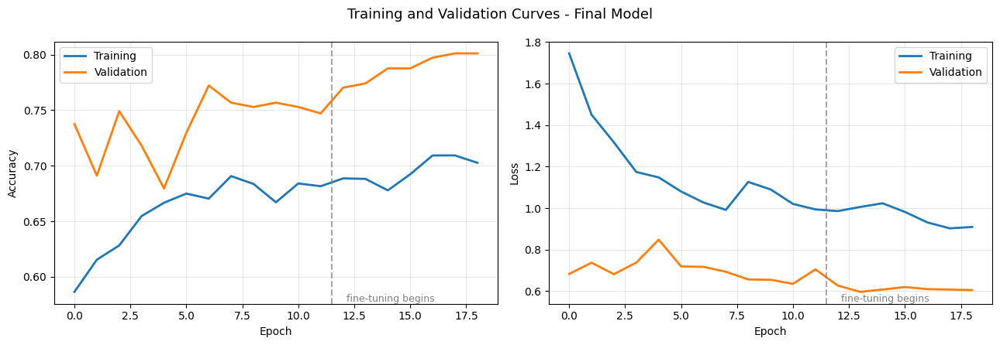

Epochs run: 19
Final training accuracy:   0.7026
Final validation accuracy: 0.8012
Generalisation gap:        -0.0985
Best validation accuracy:  0.8012 at epoch 18


In [41]:
# C29 - Plot accuracy and loss curves for the final model, marking the
# transition from head training to fine-tuning (Figure 12).
phase_split = EPOCHS_HEAD if len(best_hist["loss"]) > EPOCHS_HEAD else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, ylab in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(best_hist[metric], label="Training", linewidth=2)
    ax.plot(best_hist[f"val_{metric}"], label="Validation", linewidth=2)
    if phase_split:
        ax.axvline(phase_split - 0.5, color="grey", linestyle="--", alpha=.7)
        ax.text(phase_split, ax.get_ylim()[0], " fine-tuning begins",
                fontsize=9, color="grey", va="bottom")
    ax.set(xlabel="Epoch", ylabel=ylab); ax.legend(); ax.grid(alpha=.3)

plt.suptitle("Training and Validation Curves - Final Model", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig10_training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

gap = best_hist["accuracy"][-1] - best_hist["val_accuracy"][-1]
print(f"Epochs run: {len(best_hist['loss'])}")
print(f"Final training accuracy:   {best_hist['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {best_hist['val_accuracy'][-1]:.4f}")
print(f"Generalisation gap:        {gap:+.4f}")
print(f"Best validation accuracy:  {max(best_hist['val_accuracy']):.4f} "
      f"at epoch {int(np.argmax(best_hist['val_accuracy']))+1}")

In [42]:
# C30 - Evaluate the final model on the held-out test subset.
# This is the first and only time the test data is used.
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, cohen_kappa_score)

best_model = tf.keras.models.load_model("/kaggle/working/final_model.keras")

probs  = best_model.predict(test_ds, verbose=0)      # (519, 5) class probabilities
y_pred = probs.argmax(axis=1)
y_true = y_test

acc   = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")   # APTOS metric

majority = np.bincount(y_train).argmax()
base_acc = (y_true == majority).mean()

# Bootstrap 95% confidence intervals: with 519 test images, point estimates
# carry real uncertainty, and resampling quantifies how precise each figure is.
rng = np.random.default_rng(SEED)
boot_acc, boot_kappa = [], []
for _ in range(2000):
    idx = rng.integers(0, len(y_true), len(y_true))
    boot_acc.append(accuracy_score(y_true[idx], y_pred[idx]))
    boot_kappa.append(cohen_kappa_score(y_true[idx], y_pred[idx], weights="quadratic"))

ci = lambda v: (np.percentile(v, 2.5), np.percentile(v, 97.5))
acc_lo, acc_hi = ci(boot_acc)
kap_lo, kap_hi = ci(boot_kappa)

print(f"Test accuracy:             {acc:.4f}   95% CI [{acc_lo:.3f}, {acc_hi:.3f}]")
print(f"Quadratic weighted kappa:  {kappa:.4f}   95% CI [{kap_lo:.3f}, {kap_hi:.3f}]")
print(f"Majority-class baseline:   {base_acc:.4f}   (always predict '{CLASS_NAMES[majority]}')")
print(f"Improvement over baseline: {(acc - base_acc)*100:+.1f} percentage points")
print(f"\n{classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values()), digits=3)}")

Test accuracy:             0.7341   95% CI [0.696, 0.771]
Quadratic weighted kappa:  0.7783   95% CI [0.735, 0.819]
Majority-class baseline:   0.5106   (always predict 'No DR')
Improvement over baseline: +22.4 percentage points

               precision    recall  f1-score   support

        No DR      0.924     0.917     0.920       265
         Mild      0.439     0.569     0.496        51
     Moderate      0.616     0.652     0.634       138
       Severe      0.412     0.280     0.333        25
Proliferative      0.444     0.300     0.358        40

     accuracy                          0.734       519
    macro avg      0.567     0.544     0.548       519
 weighted avg      0.733     0.734     0.731       519



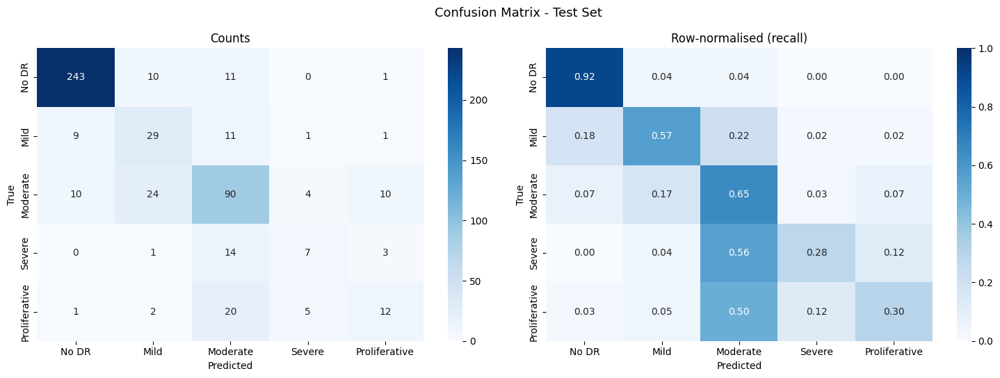

Correct:            381  (73.4%)
Off by one grade:    80  (15.4%)
Off by two or more:  58  (11.2%)

Grade 3-4 predicted as No DR: 1 of 65


In [43]:
# C31 - Confusion matrix in counts and row-normalised form (Figure 13).
# Row normalisation shows per-class recall, which raw counts obscure under imbalance.
import seaborn as sns

cm  = confusion_matrix(y_true, y_pred)
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
names = list(CLASS_NAMES.values())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=names, yticklabels=names, ax=axes[0])
axes[0].set(title="Counts", xlabel="Predicted", ylabel="True")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=names, yticklabels=names, ax=axes[1])
axes[1].set(title="Row-normalised (recall)", xlabel="Predicted", ylabel="True")
plt.suptitle("Confusion Matrix - Test Set", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig11_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

# Error severity: adjacent-grade confusion is clinically less serious
err = np.abs(y_true - y_pred)
print(f"Correct:            {(err==0).sum():3d}  ({(err==0).mean()*100:.1f}%)")
print(f"Off by one grade:   {(err==1).sum():3d}  ({(err==1).mean()*100:.1f}%)")
print(f"Off by two or more: {(err>=2).sum():3d}  ({(err>=2).mean()*100:.1f}%)")
print(f"\nGrade 3-4 predicted as No DR: {((y_true>=3)&(y_pred==0)).sum()} of {(y_true>=3).sum()}")

Referable DR screening (grades 2-4 vs 0-1), threshold 0.50
  Sensitivity (recall): 0.877
  Precision:            0.840
  F1-score:             0.858
  ROC AUC:              0.958
  Missed referable cases: 25 of 203

At threshold 0.471: sensitivity 0.901, precision 0.832, missed 20 cases


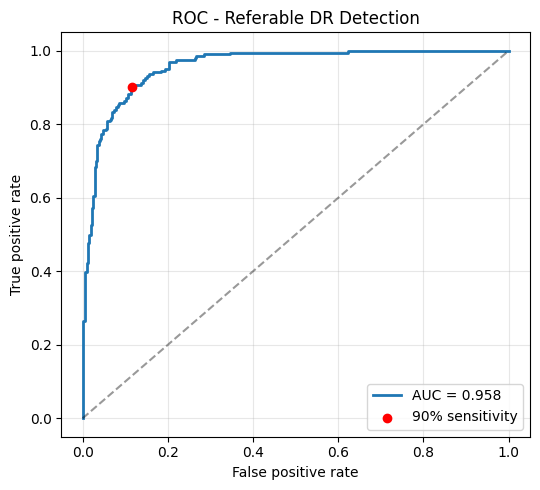

In [44]:
# C32 - Evaluate the clinically decisive task: referable disease (grades 2-4)
# versus non-referable (grades 0-1). This is how a screening tool is used.
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support

ref_true = (y_true >= 2).astype(int)
ref_prob = probs[:, 2:].sum(axis=1)                  # P(referable)
ref_pred = (ref_prob >= 0.5).astype(int)

p, r, f1, _ = precision_recall_fscore_support(ref_true, ref_pred, average="binary")
fpr, tpr, thr = roc_curve(ref_true, ref_prob)
roc_auc = auc(fpr, tpr)

print("Referable DR screening (grades 2-4 vs 0-1), threshold 0.50")
print(f"  Sensitivity (recall): {r:.3f}")
print(f"  Precision:            {p:.3f}")
print(f"  F1-score:             {f1:.3f}")
print(f"  ROC AUC:              {roc_auc:.3f}")
print(f"  Missed referable cases: {((ref_true==1)&(ref_pred==0)).sum()} of {ref_true.sum()}")

# Screening prioritises sensitivity: what threshold reaches 90%, at what cost?
i90 = np.argmax(tpr >= 0.90)
alt = (ref_prob >= thr[i90]).astype(int)
p90, r90, _, _ = precision_recall_fscore_support(ref_true, alt, average="binary")
print(f"\nAt threshold {thr[i90]:.3f}: sensitivity {r90:.3f}, precision {p90:.3f}, "
      f"missed {((ref_true==1)&(alt==0)).sum()} cases")

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.scatter([fpr[i90]], [tpr[i90]], color="red", zorder=5, label="90% sensitivity")
plt.plot([0, 1], [0, 1], "k--", alpha=.4)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC - Referable DR Detection"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig12_roc.png", dpi=200, bbox_inches="tight")
plt.show()

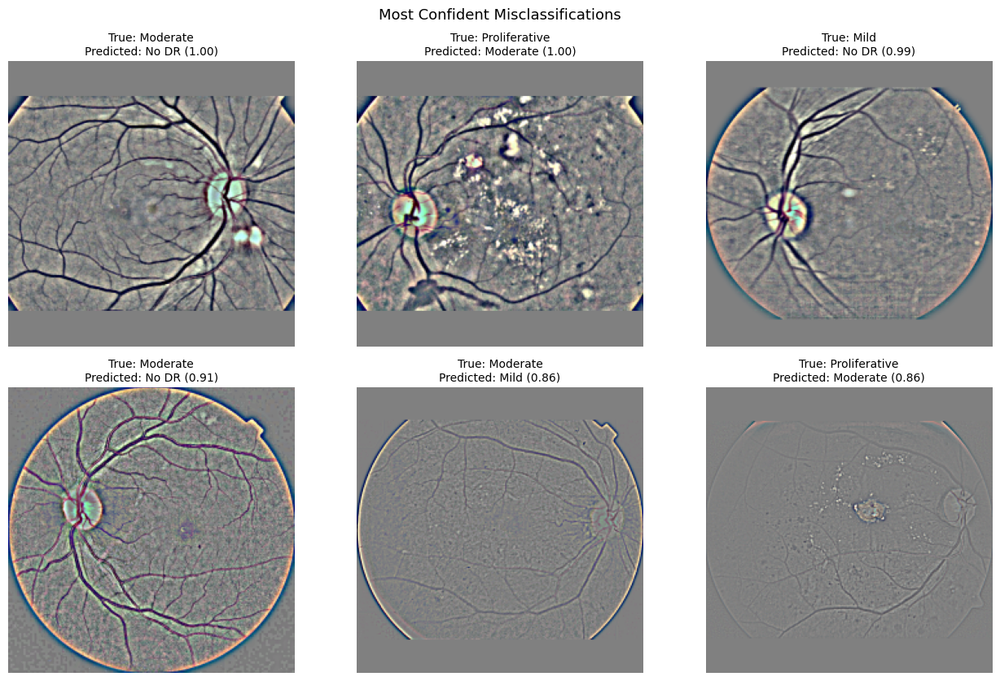

Mean confidence when correct: 0.812
Mean confidence when wrong:   0.545


In [45]:
# C33 - Inspect the most confidently wrong predictions. Confident errors indicate
# systematic failure rather than ordinary uncertainty near a decision boundary.
wrong = np.where(y_pred != y_true)[0]
conf  = probs[wrong].max(axis=1)
worst = wrong[np.argsort(-conf)][:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, i in zip(axes.flat, worst):
    ax.imshow(X_test[i]); ax.axis("off")
    ax.set_title(f"True: {CLASS_NAMES[y_true[i]]}\n"
                 f"Predicted: {CLASS_NAMES[y_pred[i]]} ({probs[i].max():.2f})", fontsize=10)
plt.suptitle("Most Confident Misclassifications", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig13_errors.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean confidence when correct: {probs[y_pred==y_true].max(axis=1).mean():.3f}")
print(f"Mean confidence when wrong:   {probs[y_pred!=y_true].max(axis=1).mean():.3f}")

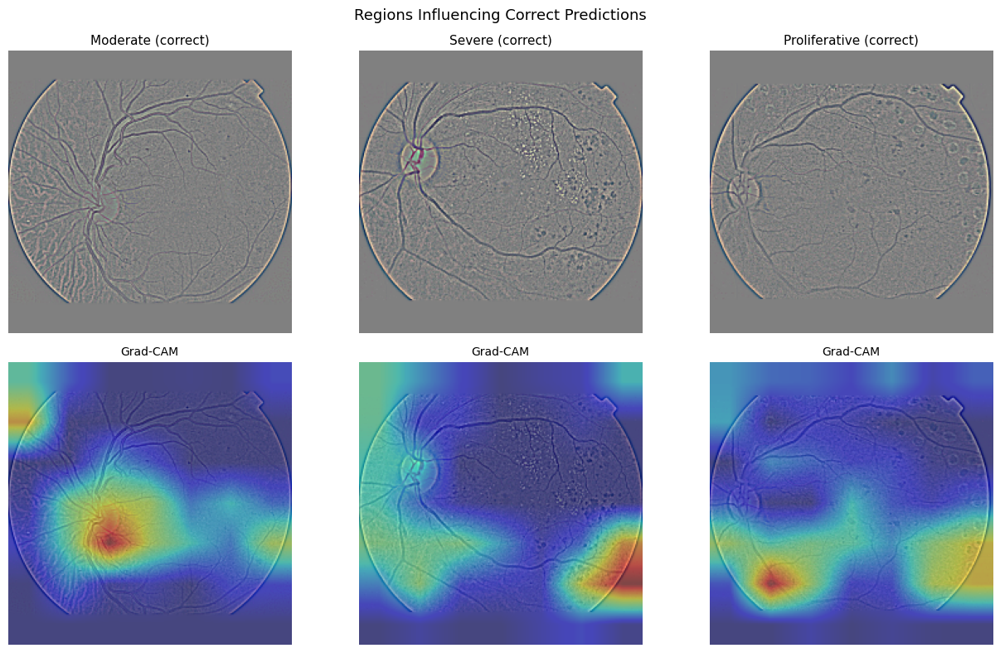

In [46]:
# C34 - Grad-CAM: highlight the image regions that most influenced each prediction.
# The backbone is nested inside the model, so the feature maps and the
# classification head are evaluated in two explicit steps.
def grad_cam(model, img, class_idx=None):
    base = [l for l in model.layers if isinstance(l, tf.keras.Model)][0]
    conv = [l for l in base.layers if len(l.output.shape) == 4][-1]
    feat_model = tf.keras.Model(base.inputs, base.get_layer(conv.name).output)

    bi = model.layers.index(base)
    head_layers = model.layers[bi + 1:]

    x = tf.expand_dims(tf.cast(img, tf.float32), 0)
    for l in model.layers[1:bi]:            # apply the model's own preprocessing
        x = l(x)

    with tf.GradientTape() as tape:
        maps = feat_model(x)
        tape.watch(maps)
        h = maps
        for l in head_layers:               # run the classification head
            h = l(h, training=False)
        idx = tf.argmax(h[0]) if class_idx is None else class_idx
        score = h[:, idx]

    grads = tape.gradient(score, maps)
    w   = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(maps[0] * w, axis=-1).numpy()
    cam = np.maximum(cam, 0)
    return cv2.resize(cam / (cam.max() + 1e-8), (IMG_SIZE, IMG_SIZE))


picks = [np.where((y_true == g) & (y_pred == g))[0][0] for g in [2, 3, 4]]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for c, i in enumerate(picks):
    axes[0, c].imshow(X_test[i]); axes[0, c].axis("off")
    axes[0, c].set_title(f"{CLASS_NAMES[y_true[i]]} (correct)", fontsize=11)
    axes[1, c].imshow(X_test[i])
    axes[1, c].imshow(grad_cam(best_model, X_test[i]), cmap="jet", alpha=0.45)
    axes[1, c].axis("off"); axes[1, c].set_title("Grad-CAM", fontsize=10)

plt.suptitle("Regions Influencing Correct Predictions", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig14_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

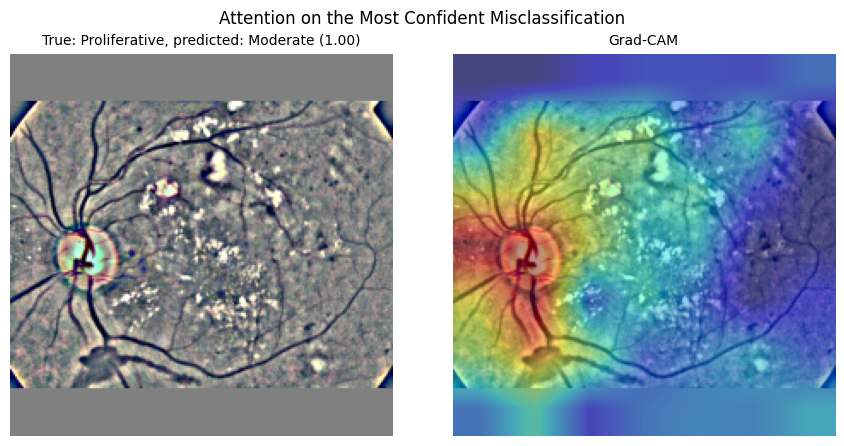

In [38]:
# C34b - Grad-CAM on the most confident error, to identify where the model
# attended when it failed most severely.
i = worst[0]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(X_test[i]); axes[0].axis("off")
axes[0].set_title(f"True: {CLASS_NAMES[y_true[i]]}, "
                  f"predicted: {CLASS_NAMES[y_pred[i]]} ({probs[i].max():.2f})", fontsize=10)
axes[1].imshow(X_test[i]); axes[1].imshow(grad_cam(best_model, X_test[i]), cmap="jet", alpha=0.45)
axes[1].axis("off"); axes[1].set_title("Grad-CAM", fontsize=10)
plt.suptitle("Attention on the Most Confident Misclassification", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig15_gradcam_error.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# C35 - Bundle all deliverables into one archive
import zipfile, glob
with zipfile.ZipFile("/kaggle/working/everything.zip", "w") as z:
    z.write("/kaggle/working/final_model.keras", "final_model.keras")
    for f in glob.glob(f"{FIG_DIR}/*.png"):
        z.write(f, f"figures/{os.path.basename(f)}")
    for f in glob.glob(f"{SPLIT_DIR}/*.csv"):
        z.write(f, f"splits/{os.path.basename(f)}")
print("Created everything.zip - refresh the Output panel and download it")

Created everything.zip - refresh the Output panel and download it


In [15]:
!cd /kaggle/working && zip -r prototype_bundle.zip final_model.keras examples/
!ls -lh /kaggle/working/prototype_bundle.zip

updating: final_model.keras (deflated 7%)
updating: examples/ (stored 0%)
updating: examples/grade2_moderate.png (deflated 0%)
updating: examples/grade4_proliferative.png (deflated 0%)
updating: examples/grade0_healthy.png (deflated 0%)
-rw-r--r-- 1 root root 211M Sep 29 04:42 /kaggle/working/prototype_bundle.zip


In [16]:
!pip install -q gradio==4.44.1

In [17]:
# ============================================================
# C35 - Task 7 prototype (Kaggle-native, no web server)
# ============================================================
import os, glob, time, cv2, numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

MODEL_PATH  = '/kaggle/working/final_model.keras'
IMG_SIZE    = 224
CLASS_NAMES = ['No DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'Proliferative DR']
REFERABLE   = [2, 3, 4]

INK, MUTED, RULE = '#1a1d23', '#6b7280', '#d8dce3'
BAR, BAR_HI      = '#c9d2e0', '#2563eb'
WARN, WARN_BG    = '#b42318', '#fef3f2'
OKC,  OK_BG      = '#067647', '#f0fdf4'

# ---------------- preprocessing: identical to Section 2.1 -------------------
def crop_retina(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    c = np.argwhere(mask)
    y0, x0 = c.min(axis=0); y1, x1 = c.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def pad_to_square(img, value=128):
    h, w = img.shape[:2]
    s = max(h, w)
    top, left = (s - h) // 2, (s - w) // 2
    return cv2.copyMakeBorder(img, top, s - h - top, left, s - w - left,
                              cv2.BORDER_CONSTANT, value=[value] * 3)

def preprocess(img_rgb):
    img = crop_retina(img_rgb)
    img = cv2.medianBlur(img, 3)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), 10), -4, 128)
    img = pad_to_square(img, 128)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

# ---------------- model -----------------------------------------------------
model = tf.keras.models.load_model(MODEL_PATH)
print('model loaded:', model.count_params(), 'parameters')

def infer(proc):
    x = np.expand_dims(proc.astype('float32'), 0)
    return np.asarray(model(x, training=False))[0]     # faster than .predict()

_ = infer(np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8))  # warm-up: builds the graph
print('model warmed up')

# ---------------- gather sample cases --------------------------------------
IMG_DIR = glob.glob('/kaggle/input/**/train_images', recursive=True)[0]

src = None
if 'test_df' in globals():
    src = test_df.copy(); print('cases from the in-memory test split')
else:
    for p in (sorted(glob.glob('/kaggle/working/**/*test*.csv', recursive=True)) +
              sorted(glob.glob('/kaggle/working/**/*split*.csv', recursive=True))):
        t = pd.read_csv(p)
        if {'id_code', 'diagnosis'}.issubset(t.columns):
            src = t; print('cases from saved split:', p); break
if src is None:
    src = pd.read_csv(glob.glob('/kaggle/input/**/train.csv', recursive=True)[0])
    print('cases from train.csv')

CASES = []
for g in [0, 2, 4, 1, 3]:
    rows = src[src['diagnosis'] == g]
    if len(rows) == 0:
        continue
    cid  = rows.iloc[0]['id_code']
    orig = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f'{cid}.png')), cv2.COLOR_BGR2RGB)
    proc = preprocess(orig)
    CASES.append(dict(name=f'{cid}.png', true=int(g),
                      orig=orig, proc=proc, probs=infer(proc)))
    print(f'  [{len(CASES)-1}] {cid}.png   true grade {g}')

print(f'\n{len(CASES)} cases ready — run show(0), show(1), ... to display')

model loaded: 24121733 parameters
model warmed up
cases from saved split: /kaggle/working/splits/test.csv
  [0] 8fbb2ca39911.png   true grade 0
  [1] 1c5e6cdc7ee1.png   true grade 2
  [2] 59fee5bc3479.png   true grade 4
  [3] f72ef9ceeaa8.png   true grade 1
  [4] b5834ee64541.png   true grade 3

5 cases ready — run show(0), show(1), ... to display


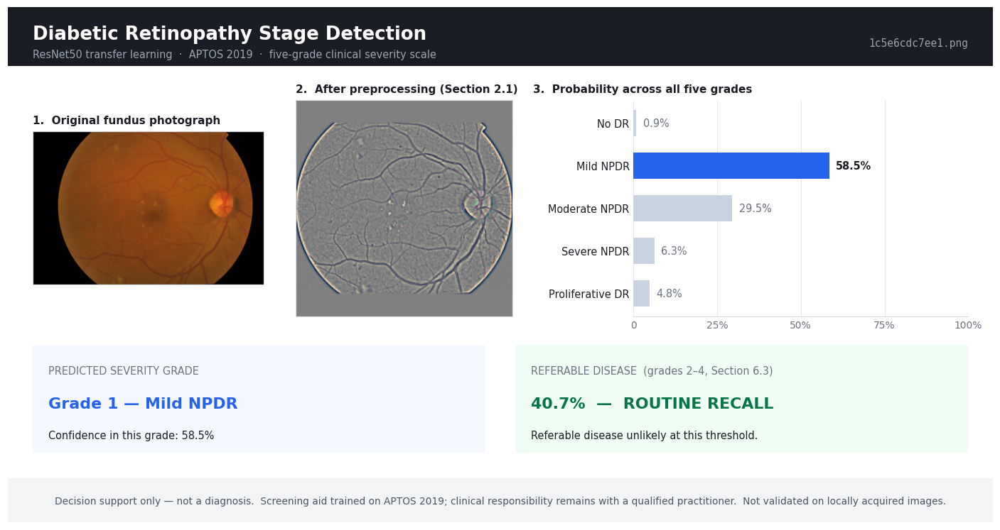

true grade 2  |  rendered in 1.05s


In [18]:
# ============================================================
# C36 - render the prototype output panel
# ============================================================
def render(orig, proc, probs, case_name):
    grade = int(np.argmax(probs))
    p_ref = float(np.sum(probs[REFERABLE]))
    refer = p_ref >= 0.5

    fig = plt.figure(figsize=(12.6, 6.6), dpi=110, facecolor='white')

    fig.patches.append(plt.Rectangle((0, 0.885), 1, 0.115, transform=fig.transFigure,
                                     facecolor=INK, zorder=0))
    fig.text(0.025, 0.947, 'Diabetic Retinopathy Stage Detection',
             color='white', fontsize=17, fontweight='bold', va='center')
    fig.text(0.025, 0.909,
             'ResNet50 transfer learning  ·  APTOS 2019  ·  five-grade clinical severity scale',
             color='#9aa4b2', fontsize=9.5, va='center')
    fig.text(0.975, 0.930, case_name, color='#9aa4b2', fontsize=9.5,
             va='center', ha='right', family='monospace')

    for rect, im, cap in [([0.025, 0.40, 0.235, 0.42], orig, '1.  Original fundus photograph'),
                          ([0.285, 0.40, 0.235, 0.42], proc, '2.  After preprocessing (Section 2.1)')]:
        ax = fig.add_axes(rect)
        ax.imshow(im); ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(RULE)
        ax.set_title(cap, fontsize=10, color=INK, fontweight='semibold', loc='left', pad=7)

    axb = fig.add_axes([0.635, 0.40, 0.34, 0.42])
    y = np.arange(5)[::-1]
    axb.barh(y, probs, color=[BAR_HI if i == grade else BAR for i in range(5)], height=0.62)
    axb.set_yticks(y); axb.set_yticklabels(CLASS_NAMES, fontsize=9.5, color=INK)
    axb.set_xlim(0, 1); axb.set_xticks([0, .25, .5, .75, 1.])
    axb.set_xticklabels(['0', '25%', '50%', '75%', '100%'], fontsize=9, color=MUTED)
    axb.set_title('3.  Probability across all five grades', fontsize=10, color=INK,
                  fontweight='semibold', loc='left', pad=7, x=-0.30)
    for s in ('top', 'right', 'left'):
        axb.spines[s].set_visible(False)
    axb.spines['bottom'].set_color(RULE)
    axb.tick_params(length=0)
    axb.grid(axis='x', color=RULE, lw=0.6, alpha=0.7); axb.set_axisbelow(True)
    for i, v in zip(y, probs):
        axb.text(min(v + 0.02, 0.97), i, f'{v:.1%}', va='center', fontsize=9.5,
                 color=INK if v == probs[grade] else MUTED,
                 fontweight='bold' if v == probs[grade] else 'normal')

    def box(x, w, title, l1, l2, fg, bg):
        ax = fig.add_axes([x, 0.135, w, 0.21]); ax.axis('off')
        ax.add_patch(FancyBboxPatch((0, 0), 1, 1, transform=ax.transAxes,
                                    boxstyle='round,pad=0.012,rounding_size=0.03',
                                    facecolor=bg, edgecolor=fg, lw=1.1, zorder=0))
        ax.text(0.035, 0.76, title, fontsize=9.5, color=MUTED, transform=ax.transAxes, va='center')
        ax.text(0.035, 0.45, l1, fontsize=14.5, color=fg, fontweight='bold',
                transform=ax.transAxes, va='center')
        ax.text(0.035, 0.16, l2, fontsize=9.5, color=INK, transform=ax.transAxes, va='center')

    box(0.025, 0.46, 'PREDICTED SEVERITY GRADE',
        f'Grade {grade} — {CLASS_NAMES[grade]}',
        f'Confidence in this grade: {probs[grade]:.1%}', BAR_HI, '#f5f8ff')
    box(0.515, 0.46, 'REFERABLE DISEASE  (grades 2–4, Section 6.3)',
        f'{p_ref:.1%}  —  ' + ('REFER' if refer else 'ROUTINE RECALL'),
        'Refer to an ophthalmologist.' if refer
        else 'Referable disease unlikely at this threshold.',
        WARN if refer else OKC, WARN_BG if refer else OK_BG)

    fig.patches.append(plt.Rectangle((0, 0), 1, 0.085, transform=fig.transFigure,
                                     facecolor='#f3f4f6', zorder=0))
    fig.text(0.5, 0.042,
             'Decision support only — not a diagnosis.  Screening aid trained on APTOS 2019; '
             'clinical responsibility remains with a qualified practitioner.  '
             'Not validated on locally acquired images.',
             fontsize=9, color='#4b5563', ha='center', va='center')
    return fig

def show(i, save=None):
    t0 = time.time()
    c = CASES[i]
    fig = render(c['orig'], c['proc'], c['probs'], c['name'])
    if save:
        fig.savefig(save, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()
    print(f"true grade {c['true']}  |  rendered in {time.time()-t0:.2f}s")

# Figure 18 for the report - use the moderate case
show(1, save='/kaggle/working/f72ef9ceeaa8.png')

In [9]:
# ============================================================
# C37 - Prototype interface  (replaces C36 and C37)
# Run after C35.
# ============================================================
import random, time, numpy as np, matplotlib.pyplot as plt
import ipywidgets as w
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, clear_output, HTML

INK, MUTED, FAINT = '#151922', '#6b7280', '#9aa3b0'
RULE            = '#e3e8ef'
BAR, BAR_HI     = '#d6dde8', '#2563eb'
OKC, OK_BG      = '#067647', '#ecfdf3'
WARN, WARN_BG   = '#b42318', '#fef3f2'
AMBER, AMBER_BG = '#b54708', '#fffaeb'


def render(orig, proc, probs, case_name, true_grade=None):
    grade = int(np.argmax(probs))
    p_ref = float(np.sum(probs[REFERABLE]))
    refer = p_ref >= 0.5

    if true_grade is None:
        chip, cfg, cbg = 'UNLABELLED', MUTED, '#eef1f6'
    elif grade == true_grade:
        chip, cfg, cbg = 'CORRECT', OKC, OK_BG
    else:
        d = grade - true_grade
        chip = f"{'UNDER' if d < 0 else 'OVER'}-GRADED BY {abs(d)}"
        cfg, cbg = AMBER, AMBER_BG

    fig = plt.figure(figsize=(13.2, 7.1), dpi=110, facecolor='white')

    # ---- header
    fig.patches.append(plt.Rectangle((0, .875), 1, .125, transform=fig.transFigure,
                                     facecolor=INK, zorder=0))
    fig.text(.028, .945, 'Diabetic Retinopathy Stage Detection', color='white',
             fontsize=17.5, fontweight='bold', va='center')
    fig.text(.028, .905, 'ResNet50 transfer learning   ·   APTOS 2019   ·   '
             'five-grade clinical severity scale', color='#98a2b3', fontsize=9.5, va='center')

    a = fig.add_axes([.760, .898, .215, .054]); a.axis('off'); a.set_zorder(6)
    a.add_patch(FancyBboxPatch((0, 0), 1, 1, transform=a.transAxes,
                               boxstyle='round,pad=0.02,rounding_size=0.22',
                               facecolor=cbg, edgecolor=cfg, lw=1.2))
    a.text(.5, .5, chip, ha='center', va='center', fontsize=10.5,
           fontweight='bold', color=cfg, transform=a.transAxes)

    fig.text(.975, .862,
             case_name + (f'    ·    true grade {true_grade}' if true_grade is not None else ''),
             color=FAINT, fontsize=9, ha='right', va='top', family='monospace')

    # ---- images
    for rect, im, num, cap in [([.028, .40, .215, .40], orig, '1', 'Original fundus photograph'),
                               ([.268, .40, .215, .40], proc, '2', 'After preprocessing (Section 2.1)')]:
        ax = fig.add_axes(rect)
        ax.imshow(im); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color(RULE); sp.set_linewidth(1.4)
        ax.set_title(f'{num}.  {cap}', fontsize=10.5, color=INK,
                     fontweight='semibold', loc='left', pad=8)

    # ---- probabilities
    axb = fig.add_axes([.615, .40, .30, .40])
    y = np.arange(5)[::-1]
    axb.barh(y, probs, height=.60, zorder=2,
             color=[BAR_HI if i == grade else BAR for i in range(5)])
    if true_grade is not None and true_grade != grade:
        axb.barh(y[true_grade], probs[true_grade], height=.60, zorder=3,
                 facecolor='none', edgecolor=OKC, lw=1.8, linestyle='--')
        axb.text(.99, 1.055, '– – –  clinician grade', transform=axb.transAxes,
                 ha='right', va='bottom', fontsize=8.8, color=OKC, fontweight='semibold')
    axb.set_yticks(y); axb.set_yticklabels(CLASS_NAMES, fontsize=10, color=INK)
    axb.set_xlim(0, 1); axb.set_xticks([0, .25, .5, .75, 1])
    axb.set_xticklabels(['0', '25%', '50%', '75%', '100%'], fontsize=9, color=MUTED)
    axb.set_title('3.  Probability across all five grades', fontsize=10.5, color=INK,
                  fontweight='semibold', loc='left', pad=8, x=-.36)
    for sp in ('top', 'right', 'left'):
        axb.spines[sp].set_visible(False)
    axb.spines['bottom'].set_color(RULE)
    axb.tick_params(length=0); axb.grid(axis='x', color=RULE, lw=.7, zorder=0)
    axb.set_axisbelow(True)
    for i, v in zip(y, probs):
        hi = (4 - i) == grade
        axb.text(min(v + .022, .96), i, f'{v:.1%}', va='center', fontsize=9.5,
                 color=INK if hi else MUTED, fontweight='bold' if hi else 'normal')

    # ---- verdict cards
    def card(x, wd, label, big, small, fg, bg):
        ax = fig.add_axes([x, .135, wd, .205]); ax.axis('off')
        ax.add_patch(FancyBboxPatch((0, 0), 1, 1, transform=ax.transAxes,
                                    boxstyle='round,pad=0.014,rounding_size=0.045',
                                    facecolor=bg, edgecolor=fg, lw=1.2, zorder=0))
        ax.text(.04, .78, label, fontsize=9, color=MUTED, transform=ax.transAxes,
                va='center', fontweight='semibold')
        ax.text(.04, .46, big, fontsize=15.5, color=fg, fontweight='bold',
                transform=ax.transAxes, va='center')
        ax.text(.04, .16, small, fontsize=9.5, color=INK, transform=ax.transAxes, va='center')

    card(.028, .455, 'PREDICTED SEVERITY GRADE',
         f'Grade {grade} — {CLASS_NAMES[grade]}',
         f'Model confidence in this grade: {probs[grade]:.1%}', BAR_HI, '#f4f8ff')
    card(.517, .455, 'REFERABLE DISEASE   (grades 2–4, Section 6.3)',
         f'{p_ref:.1%}   —   ' + ('REFER' if refer else 'ROUTINE RECALL'),
         'Refer to an ophthalmologist.' if refer
         else 'Referable disease unlikely at this threshold.',
         WARN if refer else OKC, WARN_BG if refer else OK_BG)

    # ---- footer
    fig.patches.append(plt.Rectangle((0, 0), 1, .082, transform=fig.transFigure,
                                     facecolor='#f1f4f8', zorder=0))
    fig.text(.5, .041,
             'Decision support only — not a diagnosis.   Screening aid trained on APTOS 2019; '
             'clinical responsibility remains with a qualified practitioner.   '
             'Not validated on locally acquired images.',
             fontsize=9, color='#475467', ha='center', va='center')
    return fig


# ============================================================
# Interface
# ============================================================
LABELS, _cache = dict(zip(src['id_code'], src['diagnosis'])), {}


def analyse(cid, save=None):
    path = cid if os.path.sep in str(cid) else os.path.join(IMG_DIR, f'{cid}.png')
    if path not in _cache:
        o = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        pr = preprocess(o)
        _cache[path] = (o, pr, infer(pr))
    o, pr, probs = _cache[path]
    name = os.path.basename(path)
    true = LABELS.get(os.path.splitext(name)[0])
    fig = render(o, pr, probs, name, None if true is None else int(true))
    if save:
        fig.savefig(save, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()
    return probs


POOL = []
for g in range(5):
    ids = src[src['diagnosis'] == g]['id_code'].tolist()
    POOL += [(f'Grade {g} — {NAMES_SHORT[g] if "NAMES_SHORT" in globals() else CLASS_NAMES[g]}'
              f'  ({i})', i) for i in random.sample(ids, min(5, len(ids)))]

hdr = w.HTML("<div style='font-family:system-ui;font-size:13px;font-weight:600;"
             "color:#151922;padding:2px 0 6px'>Select a case from the held-out test set</div>")
dd  = w.Dropdown(options=POOL, layout=w.Layout(width='420px'))
btn = w.Button(description='Classify', button_style='primary',
               icon='play', layout=w.Layout(width='130px'))
rnd = w.Button(description='Random case', icon='random', layout=w.Layout(width='150px'))
out = w.Output()


def run(_=None):
    with out:
        clear_output(wait=True)
        t = time.time()
        analyse(dd.value)
        print(f'rendered in {time.time()-t:.2f}s')


def pick(_):
    dd.value = random.choice(POOL)[1]
    run()


btn.on_click(run); rnd.on_click(pick)
display(w.VBox([hdr, w.HBox([dd, btn, rnd])]), out)
run()

Output()

In [9]:
# ============================================================
# C38 - system architecture diagram (standalone)
# ============================================================
import os, glob, cv2, numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK, MUTED, FILL = '#1a1d23', '#5b6470', '#f4f6f9'
TRAIN, INFER, WARN, XAI = '#64748b', '#2563eb', '#b42318', '#7c3aed'
IMG_SIZE = 224

# ---- rebuild whatever C35 would have provided ------------------------------
if 'preprocess' not in globals():
    def crop_retina(img, tol=7):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY); mask = gray > tol
        if mask.sum() == 0: return img
        c = np.argwhere(mask); y0, x0 = c.min(axis=0); y1, x1 = c.max(axis=0) + 1
        return img[y0:y1, x0:x1]

    def pad_to_square(img, value=128):
        h, w = img.shape[:2]; s = max(h, w)
        top, left = (s - h) // 2, (s - w) // 2
        return cv2.copyMakeBorder(img, top, s-h-top, left, s-w-left,
                                  cv2.BORDER_CONSTANT, value=[value]*3)

    def preprocess(img_rgb):
        img = crop_retina(img_rgb)
        img = cv2.medianBlur(img, 3)
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB); l, a, b = cv2.split(lab)
        l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
        img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
        img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), 10), -4, 128)
        return cv2.resize(pad_to_square(img, 128), (IMG_SIZE, IMG_SIZE),
                          interpolation=cv2.INTER_AREA)
    print('rebuilt preprocessing')

if 'model' not in globals():
    model = tf.keras.models.load_model('/kaggle/working/final_model.keras')
    print('model loaded:', model.count_params(), 'parameters')

# ---- pick a moderate case --------------------------------------------------
if 'CASES' in globals() and len(CASES) > 1:
    case = CASES[1]
    raw, proc, probs = case['orig'], case['proc'], case['probs']
    print('using CASES[1]')
else:
    IMG_DIR = glob.glob('/kaggle/input/**/train_images', recursive=True)[0]
    src = test_df.copy() if 'test_df' in globals() else \
          pd.read_csv(glob.glob('/kaggle/input/**/train.csv', recursive=True)[0])
    cid = src[src['diagnosis'] == 2].iloc[0]['id_code']
    raw = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f'{cid}.png')), cv2.COLOR_BGR2RGB)
    proc = preprocess(raw)
    probs = np.asarray(model(np.expand_dims(proc.astype('float32'), 0),
                             training=False))[0]
    print('built case from', cid)

cam_path = sorted(glob.glob('/kaggle/working/*gradcam*.png'))
cam = cv2.cvtColor(cv2.imread(cam_path[0]), cv2.COLOR_BGR2RGB) if cam_path else proc
print('grad-cam thumbnail:', cam_path[0] if cam_path else 'none found, using preprocessed')

using CASES[1]
grad-cam thumbnail: none found, using preprocessed


In [4]:
import os
for f in sorted(os.listdir('/kaggle/working')):
    p = os.path.join('/kaggle/working', f)
    print(f'{f:32s}', 'DIR' if os.path.isdir(p) else f'{os.path.getsize(p)/1e6:8.1f} MB')

 1c5e6cdc7ee1.png                     0.6 MB
 59fee5bc3479.png                     0.6 MB
.gradio                          DIR
.virtual_documents               DIR
EfficientNetB0_p1.keras              21.0 MB
EfficientNetB0_p2.keras              37.4 MB
ResNet50_p1.keras                   101.4 MB
ResNet50_p2.keras                   227.9 MB
everything.zip                      243.5 MB
examples                         DIR
f72ef9ceeaa8.png                      0.6 MB
fig18_prototype.png                   0.6 MB
figures                          DIR
final_history.npy                     0.0 MB
final_model.keras                   227.9 MB
gradio_tmp                       DIR
processed                        DIR
prototype_bundle.zip                220.4 MB
rep1_p1.keras                       101.4 MB
rep1_p2.keras                       227.9 MB
rep2_p1.keras                       101.4 MB
rep2_p2.keras                       227.9 MB
rep3_p1.keras                       101.4 MB
rep3_p2.keras

In [19]:
# ============================================================
# C40 - Complete accuracy audit of the final model
# Runs on the held-out test set unless you change SPLIT.
# ============================================================
import os, glob, numpy as np, pandas as pd, tensorflow as tf
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             cohen_kappa_score, matthews_corrcoef,
                             precision_recall_fscore_support, confusion_matrix,
                             roc_auc_score, log_loss, top_k_accuracy_score)

OUT, CACHE = '/kaggle/working', '/kaggle/working/processed'
NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
REFERABLE, SIGHT_THREATENING = [2, 3, 4], [3, 4]
SEED = 42

if 'model' not in globals():
    model = tf.keras.models.load_model(f'{OUT}/final_model.keras')
    print('model loaded')

def load(split):
    return np.load(f'{CACHE}/X_{split}.npy'), np.load(f'{CACHE}/y_{split}.npy')

X, y_true = load('test')
probs  = model.predict(X, batch_size=32, verbose=0)
y_pred = probs.argmax(1)
n = len(y_true)
print(f'Evaluating {n} test images\n')

# ============================================================
print('=' * 62); print('1.  OVERALL ACCURACY'); print('=' * 62)
# ============================================================
acc      = accuracy_score(y_true, y_pred)
bal_acc  = balanced_accuracy_score(y_true, y_pred)   # mean per-class recall
top2     = top_k_accuracy_score(y_true, probs, k=2, labels=range(5))
adjacent = (np.abs(y_true - y_pred) <= 1).mean()

print(f'Exact accuracy          {acc:.4f}   right grade exactly')
print(f'Balanced accuracy       {bal_acc:.4f}   mean per-class recall; ignores imbalance')
print(f'Top-2 accuracy          {top2:.4f}   true grade in the top two predictions')
print(f'Within one grade        {adjacent:.4f}   clinically the more useful number')

# ============================================================
print('\n' + '=' * 62); print('2.  AGREEMENT WITH THE CLINICIAN'); print('=' * 62)
# ============================================================
print(f"Cohen's kappa (plain)   {cohen_kappa_score(y_true, y_pred):.4f}")
print(f"Kappa (linear weights)  {cohen_kappa_score(y_true, y_pred, weights='linear'):.4f}")
print(f"Kappa (quadratic)       {cohen_kappa_score(y_true, y_pred, weights='quadratic'):.4f}   <- APTOS metric")
print(f'Matthews corr. coef.    {matthews_corrcoef(y_true, y_pred):.4f}   robust to imbalance')

# ============================================================
print('\n' + '=' * 62); print('3.  PER-CLASS'); print('=' * 62)
# ============================================================
p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=range(5), zero_division=0)
cm = confusion_matrix(y_true, y_pred, labels=range(5))
rows = []
for i in range(5):
    tp = cm[i, i]; fn = cm[i].sum() - tp; fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    rows.append({'Grade': i, 'Class': NAMES[i], 'Precision': round(p[i], 3),
                 'Recall': round(r[i], 3), 'Specificity': round(tn / (tn + fp), 3),
                 'F1': round(f1[i], 3), 'Support': sup[i]})
print(pd.DataFrame(rows).to_string(index=False))

# ============================================================
print('\n' + '=' * 62); print('4.  AVERAGED'); print('=' * 62)
# ============================================================
for avg in ['macro', 'micro', 'weighted']:
    pp, rr, ff, _ = precision_recall_fscore_support(y_true, y_pred, average=avg, zero_division=0)
    print(f'{avg.capitalize():9s}  precision {pp:.3f}   recall {rr:.3f}   F1 {ff:.3f}')

# ============================================================
print('\n' + '=' * 62); print('5.  PROBABILITY QUALITY'); print('=' * 62)
# ============================================================
onehot = np.eye(5)[y_true]
brier  = ((probs - onehot) ** 2).sum(1).mean()

def ece(yt, pr, bins=10):
    conf, pred = pr.max(1), pr.argmax(1)
    correct, e = (pred == yt), 0.0
    edges = np.linspace(0, 1, bins + 1)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            e += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return e

print(f'Log loss                {log_loss(y_true, probs, labels=range(5)):.4f}   lower is better')
print(f'Brier score             {brier:.4f}   lower is better')
print(f'Expected calib. error   {ece(y_true, probs):.4f}   0 = perfectly calibrated')
print(f'ROC AUC (macro OvR)     {roc_auc_score(y_true, probs, multi_class="ovr", average="macro"):.4f}')
print(f'ROC AUC (weighted OvR)  {roc_auc_score(y_true, probs, multi_class="ovr", average="weighted"):.4f}')
print(f'\nMean confidence when correct  {probs[y_pred == y_true].max(1).mean():.3f}')
print(f'Mean confidence when wrong    {probs[y_pred != y_true].max(1).mean():.3f}')

# ============================================================
print('\n' + '=' * 62); print('6.  CLINICAL BINARY TASKS'); print('=' * 62)
# ============================================================
def binary(pos, label, thr=0.5):
    yt = np.isin(y_true, pos).astype(int)
    pp = probs[:, pos].sum(1)
    yp = (pp >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    print(f'\n{label}  (threshold {thr})')
    print(f'  Accuracy     {(tp+tn)/len(yt):.4f}')
    print(f'  Sensitivity  {tp/(tp+fn):.4f}   of {tp+fn} positives, {fn} missed')
    print(f'  Specificity  {tn/(tn+fp):.4f}')
    print(f'  PPV          {tp/(tp+fp):.4f}      NPV  {tn/(tn+fn):.4f}')
    print(f'  F1           {2*tp/(2*tp+fp+fn):.4f}      AUC  {roc_auc_score(yt, pp):.4f}')

binary(REFERABLE, 'Referable disease (grades 2-4)')
binary(SIGHT_THREATENING, 'Sight-threatening (grades 3-4)')

# ============================================================
print('\n' + '=' * 62); print('7.  ERROR SEVERITY'); print('=' * 62)
# ============================================================
err = np.abs(y_true - y_pred)
print(f'Mean absolute error     {err.mean():.3f} grades')
for k, lab in [(0, 'Exact'), (1, 'Off by one'), (2, 'Off by two'), (3, 'Off by three'), (4, 'Off by four')]:
    c = (err == k).sum()
    if c: print(f'  {lab:14s} {c:4d}  ({c/n*100:5.1f}%)')
under = (y_pred < y_true).sum(); over = (y_pred > y_true).sum()
print(f'\nUnder-graded {under} ({under/n*100:.1f}%)   Over-graded {over} ({over/n*100:.1f}%)')
print(f'Severe/proliferative called No DR: {((y_true>=3)&(y_pred==0)).sum()} of {(y_true>=3).sum()}')

# ============================================================
print('\n' + '=' * 62); print('8.  BASELINES'); print('=' * 62)
# ============================================================
_, y_tr = load('train')
majority = np.bincount(y_tr).argmax()
prior = np.bincount(y_tr, minlength=5) / len(y_tr)
rng = np.random.default_rng(SEED)
rand_acc = np.mean([(rng.choice(5, n, p=prior) == y_true).mean() for _ in range(200)])
print(f'Always predict "{NAMES[majority]}"   {(y_true==majority).mean():.4f}')
print(f'Random, class-prior weighted   {rand_acc:.4f}')
print(f'This model                     {acc:.4f}   (+{(acc-(y_true==majority).mean())*100:.1f} pts)')

# ============================================================
print('\n' + '=' * 62); print('9.  TRAIN / VAL / TEST  (overfitting check)'); print('=' * 62)
# ============================================================
tbl = []
for sp in ['train', 'val', 'test']:
    Xs, ys = load(sp)
    ps = model.predict(Xs, batch_size=32, verbose=0).argmax(1)
    tbl.append({'Split': sp, 'n': len(ys),
                'Accuracy': round(accuracy_score(ys, ps), 4),
                'Balanced': round(balanced_accuracy_score(ys, ps), 4),
                'Kappa (quad)': round(cohen_kappa_score(ys, ps, weights='quadratic'), 4)})
t = pd.DataFrame(tbl)
print(t.to_string(index=False))
print(f"\nTrain - test gap: {t.iloc[0]['Accuracy'] - t.iloc[2]['Accuracy']:+.4f}")

# ============================================================
print('\n' + '=' * 62); print('10.  BOOTSTRAP 95% CONFIDENCE INTERVALS'); print('=' * 62)
# ============================================================
rng = np.random.default_rng(SEED)
bs = {'Accuracy': [], 'Balanced acc': [], 'Kappa (quad)': [], 'Referable AUC': []}
yt_ref, p_ref = np.isin(y_true, REFERABLE).astype(int), probs[:, REFERABLE].sum(1)
for _ in range(2000):
    i = rng.integers(0, n, n)
    bs['Accuracy'].append(accuracy_score(y_true[i], y_pred[i]))
    bs['Balanced acc'].append(balanced_accuracy_score(y_true[i], y_pred[i]))
    bs['Kappa (quad)'].append(cohen_kappa_score(y_true[i], y_pred[i], weights='quadratic'))
    if len(np.unique(yt_ref[i])) == 2:
        bs['Referable AUC'].append(roc_auc_score(yt_ref[i], p_ref[i]))
for k, v in bs.items():
    lo, hi = np.percentile(v, [2.5, 97.5])
    print(f'{k:15s} {np.mean(v):.4f}   95% CI [{lo:.3f}, {hi:.3f}]')

print('\nDone.')

I0000 00:00:1790659206.607012     159 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Evaluating 519 test images

1.  OVERALL ACCURACY
Exact accuracy          0.7341   right grade exactly
Balanced accuracy       0.5436   mean per-class recall; ignores imbalance
Top-2 accuracy          0.8863   true grade in the top two predictions
Within one grade        0.8882   clinically the more useful number

2.  AGREEMENT WITH THE CLINICIAN
Cohen's kappa (plain)   0.5899
Kappa (linear weights)  0.6946
Kappa (quadratic)       0.7783   <- APTOS metric
Matthews corr. coef.    0.5908   robust to imbalance

3.  PER-CLASS
 Grade         Class  Precision  Recall  Specificity    F1  Support
     0         No DR      0.924   0.917        0.921 0.920      265
     1          Mild      0.439   0.569        0.921 0.496       51
     2      Moderate      0.616   0.652        0.853 0.634      138
     3        Severe      0.412   0.280        0.980 0.333       25
     4 Proliferative      0.444   0.300        0.969 0.358       40

4.  AVERAGED
Macro      precision 0.567   recall 0.544   F1 0.54